In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import *
from mis_dro.experiments import ExperimentName

# from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":12})
# rc('text', usetex=True)

In [2]:
experiment_name = ExperimentName.kl_newsvendor_5d
# experiment_dir = Path(f"/Users/patrick/experiments/misdro/{experiment_name.value}")
experiment_dir = Path(f"/dcs/large/u1508153/misdro/{experiment_name.value}")
assert experiment_dir.exists()
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])

num_total_samples = []
for _, row in all_results_df.iterrows():
    if row["algorithm"] == "kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"] ** 2)
    elif row["algorithm"] == "kl_dro_bas":
        num_total_samples.append(row["num_likelihood_samples"])
all_results_df["num_total_samples"] = num_total_samples

In [3]:
# NOTE filter by DGP
filter_dgp = "multivariate_normal"
results_df = all_results_df.loc[all_results_df["dgp"] == filter_dgp]

# NOTE filter out when log_partition_constant G is less than epsilon
results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]

results_df

mean_cost     var_cost  \
uuid                                 replication                            
bc6c3f73-a9fa-4bb5-86dc-0b4ba70bfb8e 0             91.088391  2699.576715   
                                     1            104.738517  4429.964730   
                                     2            102.940029  3628.602819   
                                     3            229.878890  9126.079659   
                                     4            110.999960  1440.349716   
...                                                      ...          ...   
f1ef55d8-cc35-43c5-ab78-034e0c143154 195          104.039041  2323.567535   
                                     196          177.898763  3673.092157   
                                     197          167.388866  2391.777138   
                                     198          173.457675  2621.542445   
                                     199          154.619782  3091.818269   

                                                                                           solution  \
uuid                                 replication                                                      
bc6c3f73-a9fa-4bb5-86dc-0b4ba70bfb8e 0            [10.914234772222008, 21.52409395200534, 34.444...   
                                     1            [11.750336490691886, 19.64573822496392, 26.358...   
                                     2            [11.852527211931593, 22.509842408749318, 32.16...   
                                     3            [10.439633477014606, 15.497869601378278, 21.14...   
                                     4            [11.512984259010908, 26.49299801333609, 37.601...   
...                                                                                             ...   
f1ef55d8-cc35-43c5-ab78-034e0c143154 195          [11.559317657704923, 22.541596503166648, 36.03...   
                                     196          [9.477864310512517, 26.830877094600673, 42.889...   
                                     197          [12.885494167511895, 26.56248463631784, 44.994...   
                                     198          [11.201751184380665, 28.789127058420945, 42.02...   
                                     199          [10.775436169269028, 27.958389408385997, 42.27...   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
bc6c3f73-a9fa-4bb5-86dc-0b4ba70bfb8e 0            0.001243         0.000189   
                                     1            0.001467         0.000203   
                                     2            0.001506         0.000203   
                                     3            0.001441         0.000202   
                                     4            0.001496         0.000205   
...                                                    ...              ...   
f1ef55d8-cc35-43c5-ab78-034e0c143154 195          0.001747         0.009203   
                                     196          0.001381         0.009199   
                                     197          0.001393         0.009203   
                                     198          0.001383         0.009174   
                                     199          0.001388         0.009182   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
bc6c3f73-a9fa-4bb5-86dc-0b4ba70bfb8e 0                  0.000176    0.193928   
                                     1                  0.000211    0.031091   
                                     2                  0.000209    0.039608   
                                     3                  0.000201    0.034606   
                                     4                  0.000233    0.030278   
...                                                          ...         ...   
f1ef55d8-cc35-43c5-ab78-034e0c143154 195 

In [9]:
# agg_df = gb.agg({
#     "mean_cost": ["mean", "var"],
#     "var_cost": ["mean"],
#     "posterior_time": ["mean"],
#     "setup_time": ["mean"],
#     "solve_time": ["mean"],
    # "solution": ["mean", "var"],
# })

agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "inference", "posterior", "num_posterior_samples", "num_likelihood_samples"])
agg_df

/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:270: FutureWarning: The provided callable <function mean at 0x7f063453db20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:270: FutureWarning: The provided callable <function var at 0x7f063453dda0> is currently using SeriesGroupBy.var. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "var" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:270: FutureWarning: The provided callable <function mean at 0x7f063453db20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis

out_of_sample_mean  \
algorithm  dgp                 epsilon inference posterior              num_posterior_samples num_likelihood_samples                       
kl_bdro    multivariate_normal 0.001   bayes     normal_inverse_wishart 5                     5                               144.346061   
                                                                        10                    10                              124.357373   
                                                                        30                    30                              110.220292   
                                                                        50                    50                              109.649783   
                               0.002   bayes     normal_inverse_wishart 5                     5                               144.522475   
...                                                                                                                                  ...   
kl_dro_bas multivariate_normal 2.500   bayes     normal_inverse_wishart 1                     2500                            156.171840   
                               3.000   bayes     normal_inverse_wishart 1                     25                              141.446015   
                                                                                              100                             134.685488   
                                                                                              900                             156.145050   
                                                                                              2500                            166.430326   

                                                                                                                      out_of_sample_mean_of_vars  \
algorithm  dgp                 epsilon inference posterior              num_posterior_samples num_likelihood_samples                               
kl_bdro    multivariate_normal 0.001   bayes     normal_inverse_wishart 5                     5                                      5195.961974   
                                                                        10                    10                                     5231.090296   
                                                                        30                    30                                     4757.049261   
                                                                        50                    50                                     4798.748884   
                               0.002   bayes     normal_inverse_wishart 5                     5                                      5210.651410   
...                                                                                                                                          ...   
kl_dro_bas multivariate_normal 2.500   bayes     normal_inverse_wishart 1                     2500                                   2114.335758   
                               3.000   bayes     normal_inverse_wishart 1                     25                                     4364.572077   
                                                                                              100                                    2554.404156   
                                                                                              900                                    2200.389262   
                                                                                              2500                                   2143.592318   

                                                                                                                      out_of_sample_var_of_means  \
algorithm  dgp                 epsilon inference posterior              num_posterior_samples num_likelihood_samples                               
kl_bdro    multivariate_normal 0.001   bayes     normal_inverse_wishart 5   

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

/tmp/dcs-tmp.u1508153/ipykernel_567259/3816857561.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "is_pareto_front"] = is_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


/tmp/dcs-tmp.u1508153/ipykernel_567259/3816857561.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "is_pareto_front"] = is_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
/tmp/dcs-tmp.u1508153/ipykernel_567259/3816857561.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "is_pareto_front"] = is_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)


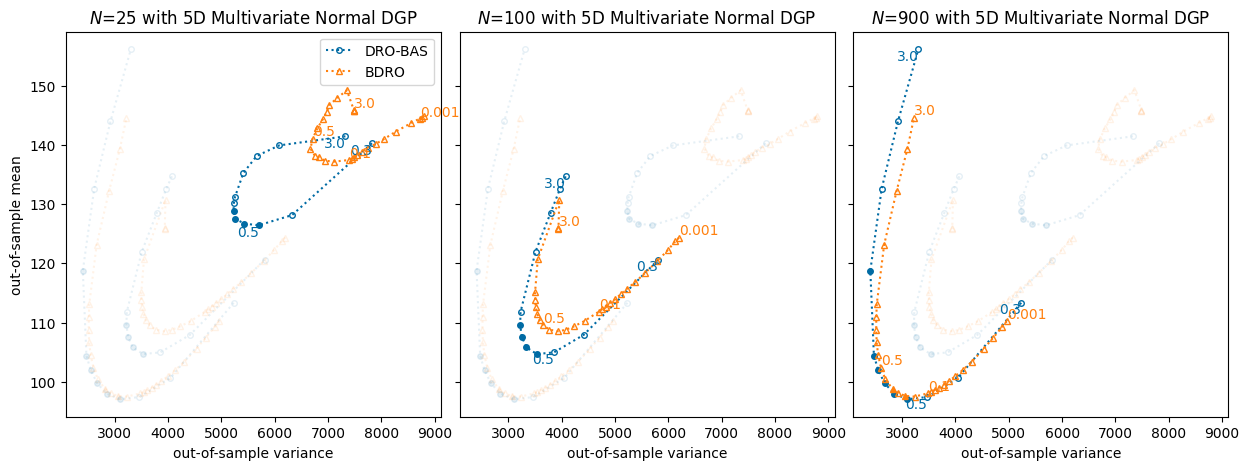

In [5]:
likelihood_sr = agg_df.index.get_level_values("num_likelihood_samples")
posterior_sr = agg_df.index.get_level_values("num_posterior_samples")

TOTAL_SAMPLES = [25, 100, 900]

nrows = len(agg_df.index.get_level_values("dgp").unique())
ncols = len(TOTAL_SAMPLES)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)
# fig.suptitle(NiceNameDGP[filter_dgp], fontsize=12)

for j, total_samples in enumerate(TOTAL_SAMPLES):
    df = agg_df.loc[(
        (likelihood_sr == int(np.sqrt(total_samples))) & (posterior_sr == int(np.sqrt(total_samples)))
        | (likelihood_sr == total_samples) & (posterior_sr == 1)
    )]
    df.loc[:, "is_minimise_pareto_front"] = is_minimise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
    df = df.reset_index(level=["num_posterior_samples", "num_likelihood_samples"], drop=True)
    gb = df.groupby("dgp")

    for k in range(len(TOTAL_SAMPLES)):
        if j == k:
            alpha = 1.0
            is_labelled = True
            axes[k].set_title("$N$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        else:
            alpha = 0.1
            is_labelled = False
        for i, (group, group_df) in enumerate(gb):
            index_set = set(
                zip(
                    group_df.index.get_level_values("algorithm"),
                    group_df.index.get_level_values("dgp"),
                    group_df.index.get_level_values("inference"),
                    group_df.index.get_level_values("posterior"),
                )
            )
            if k == 0:
                axes[k].set_ylabel("out-of-sample mean")
                axes[k].legend()
            axes[k].set_xlabel("out-of-sample variance")
            
            # add a new plot on the same axis for each parameter setting
            for algorithm, dgp, inference, posterior in index_set:
                style = algorithm_style(algorithm)
                line_label = ""
                if k == 0 and j == k:
                    line_label = style.pop("label")
                else:
                    style.pop("label")
                mean_variance_plot(axes[k], group_df.loc[algorithm, dgp, :np.inf, inference, posterior], **style, alpha=alpha, is_labelled=is_labelled, label=line_label)
# fig.savefig(f"/Users/patrick/downloads/{experiment_name}_{filter_dgp}.pdf", bbox_inches="tight")
fig.show()

## Solve time

In [6]:
results_df["is_warm_start"] = results_df.index.get_level_values("replication") == 0

# solve_time_df = results_df.groupby(["algorithm", "dgp", "num_total_samples", "is_warm_start"]).agg({"solve_time": ["mean", "std"]}).unstack(level="dgp").unstack(level="algorithm")
solve_time_df = results_df.groupby(["algorithm", "num_total_samples", "is_warm_start"]).agg({"solve_time": ["mean", "std"]}).unstack(level="algorithm").swaplevel(1,2, axis="columns")

solve_time_df


solve_time                                
algorithm                          kl_bdro kl_dro_bas   kl_bdro kl_dro_bas
                                      mean       mean       std        std
num_total_samples is_warm_start                                           
25                False           0.021581   0.021045  0.003978   0.005072
                  True            0.090382   0.046769  0.032785   0.046350
100               False           0.069394   0.115285  0.009965   0.037795
                  True            0.250966   0.099660  0.021789   0.007513
900               False           0.748535   1.403742  0.082733   0.265955
                  True           30.494229   1.337689  0.131563   0.076390
2500              False           3.142916   7.818389  0.124957   0.396536
                  True            3.177352   7.710465  0.094772   0.272650

In [7]:
print(solve_time_df.to_latex())

\begin{tabular}{llrrrr}
\toprule
 &  & \multicolumn{4}{r}{solve_time} \\
 & algorithm & kl_bdro & kl_dro_bas & kl_bdro & kl_dro_bas \\
 &  & mean & mean & std & std \\
num_total_samples & is_warm_start &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{25} & False & 0.021581 & 0.021045 & 0.003978 & 0.005072 \\
 & True & 0.090382 & 0.046769 & 0.032785 & 0.046350 \\
\cline{1-6}
\multirow[t]{2}{*}{100} & False & 0.069394 & 0.115285 & 0.009965 & 0.037795 \\
 & True & 0.250966 & 0.099660 & 0.021789 & 0.007513 \\
\cline{1-6}
\multirow[t]{2}{*}{900} & False & 0.748535 & 1.403742 & 0.082733 & 0.265955 \\
 & True & 30.494229 & 1.337689 & 0.131563 & 0.076390 \\
\cline{1-6}
\multirow[t]{2}{*}{2500} & False & 3.142916 & 7.818389 & 0.124957 & 0.396536 \\
 & True & 3.177352 & 7.710465 & 0.094772 & 0.272650 \\
\cline{1-6}
\bottomrule
\end{tabular}



# Constant $G(\tau_n)$ and expected KL

In [8]:

from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import NUM_REPLICATIONS, NUM_OBSERVATIONS, NUM_TEST_OBSERVATIONS
from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import default_prior_params, get_posterior_params, get_log_partition_constant, derive_analytical_posterior_params
from mis_dro.newsvendor import BACKORDER_COST, HOLDING_COST, newsvendor_cost_cvxpy

def normal_newsvendor_optimal_solution(dgp_mean, dgp_std):
    return sp.stats.norm.ppf(BACKORDER_COST / (BACKORDER_COST + HOLDING_COST), dgp_mean, dgp_std)


def expected_kl_normal_gamma(dgp_mean, dgp_std, theta_params):
    mu_posterior, _, alpha_posterior, beta_posterior = theta_params
    dgp_precision = 1 / (dgp_std ** 2)
    term1 = np.log(np.sqrt(dgp_precision * (beta_posterior / alpha_posterior)))
    term2 = (dgp_std ** 2 + (dgp_mean - mu_posterior)**2) / (2 * (beta_posterior / alpha_posterior))
    return term1 + term2 - 0.5 + get_log_partition_constant("normal_gamma", theta_posterior)

dgp = "multivariate_normal"
posterior = "normal_inverse_wishart"
num_observations = NUM_OBSERVATIONS
G_constant = []             # calculate the constant G
posterior_expected_kl = []  # assuming normal DGP, what is expectation under the posterior of the KL between the DGP and the likelihood?
prior_expected_kl = []      # assuming normal DGP, what is expectation under the prior of the KL between the DGP and the likelihood?
opt_sol = normal_newsvendor_optimal_solution(25, DGP_STD_TRUNCATED_NORMAL)  # optimal solution

opt_costs = np.zeros((NUM_REPLICATIONS, NUM_TEST_OBSERVATIONS))
for j in range(NUM_REPLICATIONS):
    generator = np.random.default_rng(seed=j)
    data = sample_dgp(
        dgp, num_observations, generator=generator
    )
    data_eval = sample_dgp(
        dgp, NUM_TEST_OBSERVATIONS, contamination=0.0, generator=generator
    )
    theta_prior = default_prior_params(posterior)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    G_constant.append(get_log_partition_constant(posterior, theta_posterior))
    posterior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_posterior))
    prior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_prior))
    opt_costs[j] = newsvendor_cost_cvxpy(opt_sol, data_eval).value
np.max(G_constant), np.var(G_constant)

ValueError: Dimension mismatch: array 'cov' is of shape (1, 1), but 'mean' is a vector of length 5.

In [ ]:
np.mean(posterior_expected_kl), np.var(posterior_expected_kl)

(0.08892539135699731, 0.0022999465683889984)

In [ ]:
np.mean(prior_expected_kl), np.var(prior_expected_kl)

(359.7442957726813, 0.0)

# Mean squared error between our solution and the solution under the DGP


In [ ]:
mean_cost = np.mean(opt_costs, axis=1)
var_cost = np.var(opt_costs, axis=1)
mean_of_means = np.mean(mean_cost)
mean_of_variances = np.mean(var_cost)
var_of_means = np.var(mean_cost)
opt_sol, mean_of_variances, var_of_means

(31.045853465832373, 809.5869569415518, 16.31412063772674)

In [ ]:
def multivariate_digamma(a: float, p: int) -> float:
    """The multivariate digamma function of dimension p

    Notes:
        [1] https://search.r-project.org/CRAN/refmans/CholWishart/html/mvdigamma.html
        [2] https://en.wikipedia.org/wiki/Multivariate_gamma_function#Derivatives
    """
    return np.sum([sp.special.digamma(a + (1.0-i)/2.0) for i in range(p)])

def get_normal_inverse_wishart_G_constant(dim: int, kappa_post: float) -> float:
    """Returns the constant G(tau, nu) for the normal-inverse-Wishart"""
    term1 = -0.5 * dim * np.log(2)
    print(term1)
    term2 = - 0.5 * multivariate_digamma(0.5 * (kappa_post - dim - 2), dim)
    print(term2)
    term3 = dim / (2 * kappa_post)
    print(term3)
    term4 = dim * 0.5 * np.log(kappa_post - dim - 2)
    print(term4)
    # term5 = 0.5 * np.log(dim)
    # print(term5)
    return term1 + term2 + term3 + term4

In [ ]:
dim = 5
_, kappa_prior, _, _ = default_prior_params("normal_inverse_wishart", dim=dim)
kappa_post = kappa_prior +  20
kappa_prior, kappa_post

(13.0, 33.0)

In [ ]:
get_normal_inverse_wishart_G_constant(dim, kappa_post)

-1.7328679513998633
-6.208643562685282
0.07575757575757576
8.145241345053705


0.2794874067261359